In [ ]:
import os

In [ ]:
# Useful if you run this on google colab and downloaded the data into your drive.
# If you run the notebook in other environment remove these lines and change the 'pd.read_csv()' function in this notebook to read from
# where you saved you data
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# activate R magic
%load_ext rpy2.ipython

In [ ]:
%%R

# Install required packages
install.packages("xgboost")
install.packages("data.table")
install.packages("arrow")
install.packages("reticulate")  # For accessing Python drive.mount
install.packages("googledrive")

library(xgboost)
library(data.table)
library(arrow)
library(reticulate)
library("googledrive")


    an issue that caused a segfault when used with rpy2:
    https://github.com/rstudio/reticulate/pull/1188
    Make sure that you use a version of that package that includes
    the fix.
    

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
trying URL 'https://cran.rstudio.com/src/contrib/xgboost_1.7.11.1.tar.gz'
Content type 'application/x-gzip' length 1085939 bytes (1.0 MB)
downloaded 1.0 MB


The downloaded source packages are in
	‘/tmp/Rtmp2AM5YA/downloaded_packages’
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
trying URL 'https://cran.rstudio.com/src/contrib/data.table_1.17.8.tar.gz'
Content type 'application/x-gzip' length 5808720 bytes (5.5 MB)
downloaded 5.5 MB


The downloaded source packages are in
	‘/tmp/Rtmp2AM5YA/downloaded_packages’
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
also installing the dependency ‘assertthat’

trying URL 'https://cran.rstudio.com/src/contrib/assertthat_0.2.1.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/arrow_21.0.0.1.tar.gz'

The downloaded source packages are in
	‘/tmp/Rtmp2AM5YA/downloaded_packages’
Installing pac

In [ ]:
%%R
install.packages("checkmate")
install.packages("foreach")
install.packages("scico")
install.packages("glex", repos = "https://plantedml.r-universe.dev")

library(glex)


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
trying URL 'https://cran.rstudio.com/src/contrib/checkmate_2.3.3.tar.gz'
Content type 'application/x-gzip' length 261479 bytes (255 KB)
downloaded 255 KB


The downloaded source packages are in
	‘/tmp/Rtmp2AM5YA/downloaded_packages’
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
also installing the dependency ‘iterators’

trying URL 'https://cran.rstudio.com/src/contrib/iterators_1.0.14.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/foreach_1.5.2.tar.gz'

The downloaded source packages are in
	‘/tmp/Rtmp2AM5YA/downloaded_packages’
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
trying URL 'https://cran.rstudio.com/src/contrib/scico_1.5.0.tar.gz'
Content type 'application/x-gzip' length 263953 bytes (257 KB)
downloaded 257 KB


The downloaded source packages are in
	‘/tmp/Rtmp2AM5YA/downloaded_packages’
Installing package into ‘

In [ ]:
%%R

# Set the path to your Parquet file - use the KDD_cup_small_test
file_path <- "drive/MyDrive/PATH_TO_DATA_CREATED_IN_THE_Preprocess_Data_NOTEBOOK.parquet"

# Read Parquet file into a data.table
df <- as.data.table(read_parquet(file_path))

# Show data preview

excluded_prefixes <- c("dst_host", "service", "protocol_type", "target")

cols <- names(df)
filtered_cols <- cols[!grepl(paste0("^(", paste(excluded_prefixes, collapse="|"), ")"), cols)]

print(filtered_cols)

df_smaller <- df[, ..filtered_cols]

 [1] "duration"           "src_bytes"          "dst_bytes"         
 [4] "land"               "wrong_fragment"     "urgent"            
 [7] "hot"                "num_failed_logins"  "logged_in"         
[10] "num_compromised"    "root_shell"         "su_attempted"      
[13] "num_root"           "num_file_creations" "num_shells"        
[16] "num_access_files"   "num_outbound_cmds"  "is_host_login"     
[19] "is_guest_login"     "count"              "srv_count"         
[22] "serror_rate"        "srv_serror_rate"    "rerror_rate"       
[25] "srv_rerror_rate"    "same_srv_rate"      "diff_srv_rate"     
[28] "srv_diff_host_rate" "flag_SF"            "flag_S0"           
[31] "flag_REJ"           "flag_RSTR"          "flag_RSTO"         
[34] "flag_SH"            "flag_S1"            "flag_S2"           
[37] "flag_RSTOS0"        "flag_OTH"           "flag_S3"           


In [ ]:
%%R

dim(df)

[1] 311029    122


In [ ]:
%%R

# Define target column and features
target_col <- "target"  # change this to your label column

X <- as.matrix(df_smaller)
y <- df[[target_col]]

# Prepare for XGBoost
dtrain <- xgb.DMatrix(data = X, label = y)

# Train model
params <- list(
  objective = "reg:squarederror",  # or "binary:logistic"
  max_depth = 6,
  eta = 0.1,
  nthread = 2
)

In [ ]:
%%R

xgb_model = xgboost(data = X, label = y,
              params = list(max_depth = 6, eta = .1),
              nrounds = 100, verbose = 0)

               Feature         Gain        Cover    Frequency
                <char>        <num>        <num>        <num>
 1:              count 6.439635e-01 1.774376e-01 0.1230219500
 2:          dst_bytes 1.862701e-01 1.863564e-01 0.1733027055
 3:           duration 5.403706e-02 8.687764e-02 0.1436957631
 4:          src_bytes 4.610562e-02 1.046330e-01 0.2151607963
 5:                hot 3.434761e-02 1.073736e-02 0.0255232261
 6:            flag_SF 7.613392e-03 1.180282e-03 0.0096988259
 7:          srv_count 7.579659e-03 1.391909e-02 0.0648289944
 8: srv_diff_host_rate 7.524281e-03 3.823819e-02 0.0398162328
 9:          logged_in 5.204599e-03 7.395630e-03 0.0206738132
10:  num_failed_logins 3.854675e-03 3.763808e-02 0.0257784584
11:     wrong_fragment 1.428456e-03 6.592518e-02 0.0181214906
12:      same_srv_rate 3.210944e-04 6.749193e-03 0.0135273099
13:        rerror_rate 3.175203e-04 2.182715e-03 0.0119959163
14:    srv_serror_rate 2.097797e-04 2.334008e-03 0.0071465033
15:     

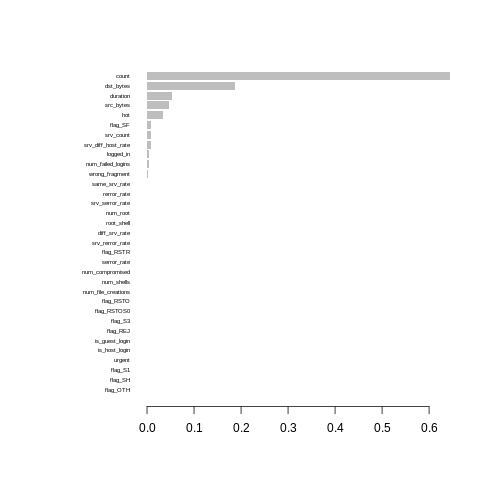

In [ ]:
%%R

# Show feature importance
importance <- xgb.importance(model = xgb_model)
print(importance)
xgb.plot.importance(importance)

Most important features:

"count", "dst_bytes", "duration", "src_bytes", "hot", "flag_SF", "srv_count", "srv_diff_host_rate", "logged_in", "num_failed_logins"

# FastPD running times

In [ ]:
%%R

# Model with 3 features

most_important_features <- c("count", "dst_bytes", "duration")
df_much_smaller <- df[, ..most_important_features]

X <- as.matrix(df_much_smaller)
xgb_small_model = xgboost(data = X, label = y,
              params = list(max_depth = 6, eta = .1),
              nrounds = 100, verbose = 0)

start <- Sys.time()
glex_xgb <- glex(xgb_small_model, X)
end <- Sys.time()
end - start

Time difference of 47.74991 secs


In [ ]:
%%R

# Model with 4 features

most_important_features <- c("count", "dst_bytes", "duration", "src_bytes")
df_much_smaller <- df[, ..most_important_features]

X <- as.matrix(df_much_smaller)
xgb_small_model = xgboost(data = X, label = y,
              params = list(max_depth = 6, eta = .1),
              nrounds = 100, verbose = 0)

start <- Sys.time()
glex_xgb <- glex(xgb_small_model, X)
end <- Sys.time()
end - start

Time difference of 1.99868 mins


In [ ]:
%%R

# Model with 5 features

most_important_features <- c("count", "dst_bytes", "duration", "src_bytes", "hot")
df_much_smaller <- df[, ..most_important_features]

X <- as.matrix(df_much_smaller)
xgb_small_model = xgboost(data = X, label = y,
              params = list(max_depth = 6, eta = .1),
              nrounds = 100, verbose = 0)

start <- Sys.time()
glex_xgb <- glex(xgb_small_model, X)
end <- Sys.time()
end - start

Time difference of 3.721896 mins


In [ ]:
%%R

# Model with 6 features

most_important_features <- c("count", "dst_bytes", "duration", "src_bytes", "hot", "flag_SF")
df_much_smaller <- df[, ..most_important_features]

X <- as.matrix(df_much_smaller)
xgb_small_model = xgboost(data = X, label = y,
              params = list(max_depth = 6, eta = .1),
              nrounds = 100, verbose = 0)

start <- Sys.time()
glex_xgb <- glex(xgb_small_model, X)
end <- Sys.time()
end - start

Time difference of 6.132742 mins


In [ ]:
%%R

# Model with 7 features

most_important_features <- c("count", "dst_bytes", "duration", "src_bytes", "hot", "flag_SF", "srv_count")
df_much_smaller <- df[, ..most_important_features]

X <- as.matrix(df_much_smaller)
xgb_small_model = xgboost(data = X, label = y,
              params = list(max_depth = 6, eta = .1),
              nrounds = 100, verbose = 0)

start <- Sys.time()
glex_xgb <- glex(xgb_small_model, X)
end <- Sys.time()
end - start

Time difference of 12.36171 mins


In [ ]:
%%R

# Model with 8 features

most_important_features <- c("count", "dst_bytes", "duration", "src_bytes", "hot", "flag_SF", "srv_count", "srv_diff_host_rate")
df_much_smaller <- df[, ..most_important_features]

X <- as.matrix(df_much_smaller)
xgb_small_model = xgboost(data = X, label = y,
              params = list(max_depth = 6, eta = .1),
              nrounds = 100, verbose = 0)

start <- Sys.time()
glex_xgb <- glex(xgb_small_model, X)
end <- Sys.time()
end - start

Time difference of 20.27911 mins


In [ ]:
%%R

# Model with 9 features

most_important_features <- c("count", "dst_bytes", "duration", "src_bytes", "hot", "flag_SF", "srv_count", "srv_diff_host_rate", "logged_in")
df_much_smaller <- df[, ..most_important_features]

X <- as.matrix(df_much_smaller)
xgb_small_model = xgboost(data = X, label = y,
              params = list(max_depth = 6, eta = .1),
              nrounds = 100, verbose = 0)

start <- Sys.time()
glex_xgb <- glex(xgb_small_model, X)
end <- Sys.time()
end - start

Time difference of 33.92659 mins
